In [6]:
# Quetion 1
import pandas as pd

In [7]:
Account_Fact = pd.read_csv(r'Account_Fact(F).csv')

In [8]:
Customer_Dim = pd.read_csv(r'Customer_Dim(F).csv')

In [9]:
# marge
Bank_Customer_Churn = pd.merge(Account_Fact, Customer_Dim, on='customer_id')

In [11]:
print(Bank_Customer_Churn.shape)

(10000, 12)


In [13]:
Bank_Customer_Churn.head()

,customer_id,credit_score,balance,products_number,credit_card,active_member,estimated_salary,churn,country,gender,age,tenure
0,15634602,619,0.00,1,1,1.0,101348.88,1,France,Female,42,2
1,15647311,608,83807.86,1,0,1.0,112542.58,0,Spain,Female,41,1
2,15619304,502,159660.80,3,1,0.0,113931.57,1,France,Female,42,8
3,15701354,699,0.00,2,0,0.0,93826.63,0,France,Female,39,1
4,15737888,850,125510.82,1,1,1.0,79084.10,0,Spain,Female,43,2


In [36]:
Bank_Customer_Churn.describe()

,customer_id,credit_score,balance,products_number,credit_card,active_member,estimated_salary,churn,age,tenure
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,85134.937180,1.530200,0.70550,0.512000,100162.821259,0.203700,38.792000,5.012800
std,7.193619e+04,96.653299,70350.098454,0.581654,0.45584,0.499881,54553.390897,0.402769,9.940021,2.892174
min,1.556570e+07,350.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,18.000000,0.000000
25%,1.562853e+07,584.000000,0.000000,1.000000,0.00000,0.000000,56290.632500,0.000000,32.000000,3.000000
50%,1.569074e+07,652.000000,97328.050000,1.000000,1.00000,1.000000,100162.820000,0.000000,38.000000,5.000000
75%,1.575323e+07,718.000000,130806.562500,2.000000,1.00000,1.000000,143890.020000,0.000000,43.000000,7.000000
max,1.581569e+07,850.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,92.000000,10.000000


In [37]:
Bank_Customer_Churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   balance           10000 non-null  float64
 3   products_number   10000 non-null  int64  
 4   credit_card       10000 non-null  int64  
 5   active_member     10000 non-null  float64
 6   estimated_salary  10000 non-null  float64
 7   churn             10000 non-null  int64  
 8   country           10000 non-null  object 
 9   gender            10000 non-null  object 
 10  age               10000 non-null  int64  
 11  tenure            10000 non-null  int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 937.6+ KB


In [15]:
print("Churn column ni unique values:", Bank_Customer_Churn['churn'].unique())

Churn column ni unique values: [1 0]


In [16]:
x = Bank_Customer_Churn.drop(['churn', 'customer_id'], axis=1)

In [17]:
y = Bank_Customer_Churn['churn']  # Target variable

In [20]:
print("Shape of X:", x.shape)

Shape of X: (10000, 10)


In [19]:
print("Shape of y:", y.shape)

Shape of y: (10000,)


In [21]:
# Quetion 2
print(x.dtypes)

credit_score          int64
balance             float64
products_number       int64
credit_card           int64
active_member       float64
estimated_salary    float64
country              object
gender               object
age                   int64
tenure                int64
dtype: object


In [24]:
print("Categorical Columns:", x.select_dtypes(include=['object']).columns.tolist())

Categorical Columns: ['country', 'gender']


In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
le = LabelEncoder()

In [27]:
x['country'] = le.fit_transform(x['country'])

In [28]:
x['gender'] = le.fit_transform(x['gender'])

In [29]:
print(x[['country', 'gender']].head())

   country  gender
0        0       0
1        3       0
2        0       0
3        0       0
4        3       0


In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
numerical_cols = ['credit_score', 'balance', 'estimated_salary', 'age', 'tenure']

In [32]:
scaler = StandardScaler()

In [33]:
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])

In [35]:
x.head()

,credit_score,balance,products_number,credit_card,active_member,estimated_salary,country,gender,age,tenure
0,-0.326221,-1.210221,1,1,1.0,0.021742,0,0,0.322752,-1.041760
1,-0.440036,-0.018865,1,0,1.0,0.226941,3,0,0.222143,-1.387538
2,-1.536794,1.059410,3,1,0.0,0.252403,0,0,0.322752,1.032908
3,0.501521,-1.210221,2,0,0.0,-0.116152,0,0,0.020927,-1.387538
4,2.063884,0.573957,1,1,1.0,-0.386406,3,0,0.423360,-1.041760


In [38]:
# Quetion 3
import matplotlib.pyplot as plt
import seaborn as sns

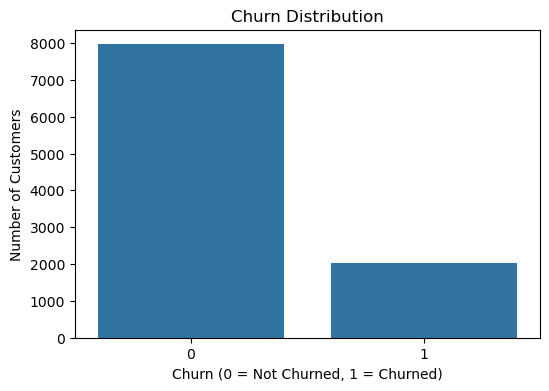

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x=Bank_Customer_Churn['churn'])
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = Not Churned, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

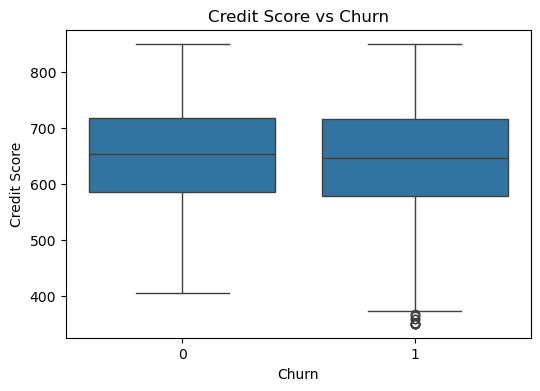

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x=Bank_Customer_Churn['churn'], y=Bank_Customer_Churn['credit_score'])
plt.title('Credit Score vs Churn')
plt.xlabel('Churn')
plt.ylabel('Credit Score')
plt.show()

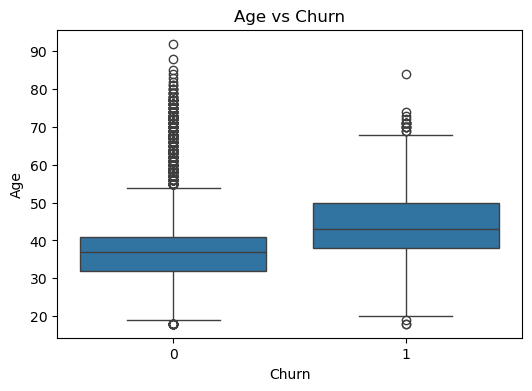

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x=Bank_Customer_Churn['churn'], y=Bank_Customer_Churn['age'])
plt.title('Age vs Churn')
plt.xlabel('Churn')
plt.ylabel('Age')
plt.show()

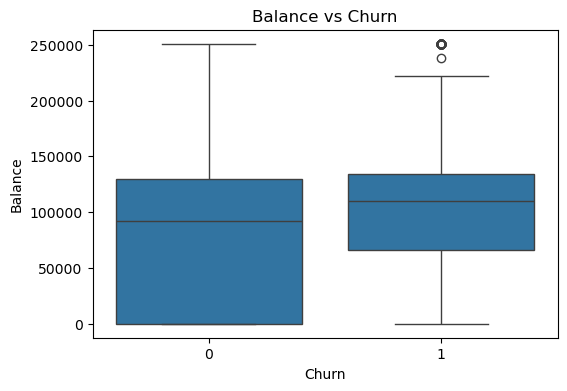

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x=Bank_Customer_Churn['churn'], y=Bank_Customer_Churn['balance'])
plt.title('Balance vs Churn')
plt.xlabel('Churn')
plt.ylabel('Balance')
plt.show()

In [44]:
# Quetion 4
from sklearn.model_selection import train_test_split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [46]:
print("Training data shape:", x_train.shape)

Training data shape: (8000, 10)


In [47]:
print("Testing data shape:", x_test.shape)

Testing data shape: (2000, 10)


In [48]:
from sklearn.svm import SVC

In [49]:
svm_model = SVC()

In [50]:
svm_model.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [51]:
y_pred_svm = svm_model.predict(x_test)

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [53]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_svm))

Accuracy Score: 0.845


In [54]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Confusion Matrix:
[[1576   31]
 [ 279  114]]


In [55]:
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1607
           1       0.79      0.29      0.42       393

    accuracy                           0.84      2000
   macro avg       0.82      0.64      0.67      2000
weighted avg       0.84      0.84      0.81      2000



In [56]:
# Quetion 5
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [57]:
rf_model = RandomForestClassifier(random_state=42)

In [59]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
y_pred_rf = rf_model.predict(x_test)

In [61]:
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))

Accuracy Score: 0.8565


In [62]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix:
[[1542   65]
 [ 222  171]]


In [63]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1607
           1       0.72      0.44      0.54       393

    accuracy                           0.86      2000
   macro avg       0.80      0.70      0.73      2000
weighted avg       0.84      0.86      0.84      2000

